[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-2-ml-dl-essentials/05-training-in-practice/code/notebook.ipynb)

# Class 2.5: Training in practice

The five-line loop from class 2.4 (PyTorch fundamentals), wrapped in a real workflow: pick the device first, batch the data, train over epochs, watch the curves, keep the best epoch, then save and reload.

What we will cover:
- pick the device up front, so the same code runs on CPU or GPU
- load the digits and split three ways: train, validation, test
- a network with batch normalization and dropout
- a training loop that validates each epoch and keeps the best
- learning curves, an honest test score, and save then reload

## Device first

Decide the device once, at the top. Every tensor and the model move to it, so the same notebook runs unchanged on a CPU or a GPU.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1)
print("using device:", device)

using device: cuda


## Load the digits and split three ways

Train to learn on, validation to choose when to stop, test for one honest score at the end.

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

X, y = load_digits(return_X_y=True)
X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=1, stratify=y_tv)
print("sizes train/val/test:", len(X_tr), len(X_val), len(X_te))

sizes train/val/test: 1077 360 360


## Scale the features and make tensors

Fit the scaler on the training set only, then reuse it. The full validation and test sets are small, so we move them to the device once; training batches move over inside the loop.

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(X_tr)
def to_t(a): return torch.tensor(sc.transform(a), dtype=torch.float32)

X_tr_t = to_t(X_tr)
y_tr_t = torch.tensor(y_tr)
X_val_t, y_val_t = to_t(X_val).to(device), torch.tensor(y_val).to(device)
X_te_t,  y_te_t  = to_t(X_te).to(device),  torch.tensor(y_te).to(device)
print("feature tensor shape:", X_tr_t.shape)

feature tensor shape: torch.Size([1077, 64])


## A DataLoader hands out batches

Wrap the training tensors and let the loader yield shuffled batches of 32.

In [4]:
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

xb, yb = next(iter(train_loader))
print("first batch:", xb.shape, yb.shape)

first batch: torch.Size([32, 64]) torch.Size([32])


## Define the network

One hidden layer, with batch normalization to steady training and dropout to fight overfitting, matching the slides. The model moves to the device.

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1  = nn.Linear(64, 64)
        self.bn1  = nn.BatchNorm1d(64)     # normalize the hidden pre-activations
        self.drop = nn.Dropout(0.3)        # zero 30% of activations in training
        self.fc2  = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)                 # raw logits

model = Net().to(device)
print(model)

Net(
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


## Loss and optimizer

Cross-entropy for the ten-class problem, Adam to take the steps.

In [6]:
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

## Train, validate each epoch, keep the best

Each batch moves to the device, then the five-line loop runs. After each epoch we score the validation set with learning off and remember the best weights.

In [7]:
train_losses, val_losses = [], []
best_val, best_epoch, best_state = float("inf"), -1, None

for epoch in range(40):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * len(xb)
    train_losses.append(running / len(X_tr_t))

    model.eval()
    with torch.no_grad():
        val_losses.append(loss_fn(model(X_val_t), y_val_t).item())
    if val_losses[-1] < best_val:
        best_val, best_epoch = val_losses[-1], epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

print(f"best validation loss {best_val:.3f} at epoch {best_epoch}")

best validation loss 0.090 at epoch 31


## The learning curves

Both losses per epoch. The dashed line marks the best validation epoch, where we stop.

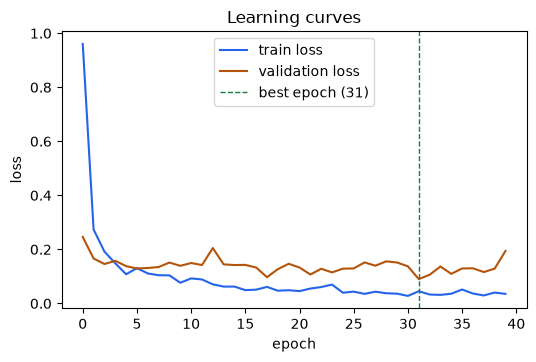

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(6, 3.6))
plt.plot(train_losses, label="train loss", color="#2563eb")
plt.plot(val_losses, label="validation loss", color="#b45309")
plt.axvline(best_epoch, color="#15803d", ls="--", lw=1, label=f"best epoch ({best_epoch})")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Learning curves")
plt.show()

## Honest test accuracy from the best epoch

Load the best weights, switch to eval mode, and score the held-out test set once.

In [9]:
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    test_acc = (model(X_te_t).argmax(1) == y_te_t).float().mean()
print("test accuracy:", round(float(test_acc), 3))

test accuracy: 0.969


## Save and reload the weights

The state dict holds the learned numbers. Save it, then load it into a fresh model of the same shape on the same device. `map_location` keeps the load device-safe.

In [10]:
import tempfile, os

path = os.path.join(tempfile.gettempdir(), "digits_model.pt")
torch.save(model.state_dict(), path)

fresh = Net().to(device)
fresh.load_state_dict(torch.load(path, map_location=device))
fresh.eval()
with torch.no_grad():
    same = torch.equal(model(X_te_t).argmax(1), fresh(X_te_t).argmax(1))
print("saved to:", os.path.basename(path))
print("identical predictions after reload:", same)

saved to: digits_model.pt
identical predictions after reload: True


## Inner layers are a representation

Stop at the hidden layer and read the vector it produces. This learned representation is the bridge to embeddings in Module 3 (NLP to Transformers).

In [11]:
model.eval()
with torch.no_grad():
    x1 = X_te_t[:1]                              # keep the batch dimension for batch norm
    hidden = torch.relu(model.bn1(model.fc1(x1)))[0]
print("representation length:", hidden.shape[0])
print("first 8 numbers:", hidden[:8].round(decimals=2).tolist())

representation length: 64
first 8 numbers: [0.0, 1.6399999856948853, 2.259999990463257, 0.9399999976158142, 2.2899999618530273, 2.109999895095825, 0.0, 0.0]


## Your turn

**Micro-assignment.** Six problems; see `../micro-assignment/README.md`.

**Next, the Module 2 milestone:** train, validate, and save a network on a real tabular dataset, plot the curves, and name where it overfits.